Running FFT for a random image. Need to subtract the average height because otherwise we will just get a black image on the output since the average (0 frequency, or the DC component) will dominate this. Apparently, this is common in AFM.

For quantum dots FFT is mostly usedful for: 
1. Detecting periodicity/ order 
2. Detecting scan artefacts
3. separating length scales 
4. estimating characteristic dot spacing -> HOW 
5. Designing filters 

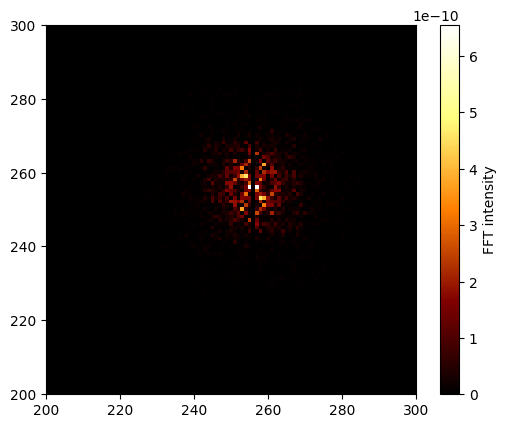

In [4]:
import numpy as np
import matplotlib.pyplot as plt

z = np.load("data_numpy/2nm_QD_AFMs_AIX6461_along_the_flat_edge_1um_200pN_15gain_2um_zrange.0_00000/channel_00___0_data.npy")
z_nobackground = z - np.mean(z)
F = np.fft.fftshift(np.fft.fft2(z_nobackground))

power = np.abs(F)**2

plt.imshow(np.log(power + 1), cmap="afmhot")
plt.colorbar(label="FFT intensity")

plt.xlim(200, 300)
plt.ylim(200, 300)

plt.show()

However, the range is very high. So, lets take the magnitude and plot it on the log scale: 

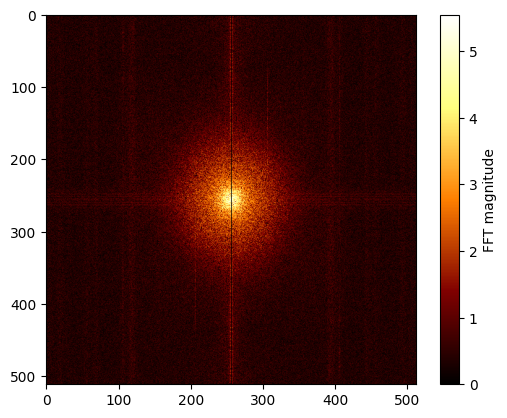

In [17]:
magnitude = np.abs(F)*10e6

plt.imshow(
    np.log1p(magnitude),
    cmap="afmhot"
)

plt.colorbar(label="FFT magnitude")
plt.show()

Using Gaussian filtering, remove the low-frequency background

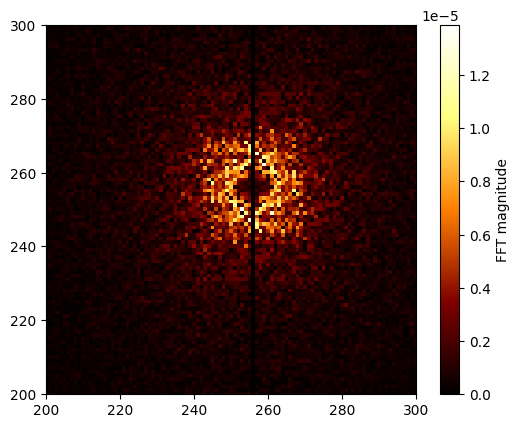

In [18]:
from scipy.ndimage import gaussian_filter

background = gaussian_filter(z, sigma=20)

z_filtered = z - background

F = np.fft.fftshift(np.fft.fft2(z_filtered))

plt.imshow(
    np.log1p(np.abs(F)),
    cmap="afmhot"
)

plt.colorbar(label="FFT magnitude")

plt.xlim(200, 300)
plt.ylim(200, 300)

plt.show()

FFT band-pass filter function testing

In [19]:
from __future__ import annotations

import numpy as np
from scipy.ndimage import gaussian_filter


def fft_bandpass(
    image: np.ndarray,
    low_sigma: float = 1,
    high_sigma: float = 10,
) -> np.ndarray:
    """
    Band-pass filter an AFM image using Fourier space.

    Keeps intermediate spatial frequencies:
    - removes slow background variations
    - removes high-frequency noise

    Parameters
    ----------
    image:
        2D AFM height array

    low_sigma:
        Controls removal of high-frequency noise.
        Smaller = keep finer details.

    high_sigma:
        Controls removal of background.
        Larger = remove larger structures.

    Returns
    -------
    filtered_image:
        Band-pass filtered AFM image
    """

    image = np.asarray(image, dtype=float)

    # remove mean height
    image = image - np.mean(image)

    # FFT
    F = np.fft.fftshift(np.fft.fft2(image))

    ny, nx = image.shape

    y, x = np.indices(image.shape)

    cx = nx // 2
    cy = ny // 2

    r = np.sqrt(
        (x - cx)**2 +
        (y - cy)**2
    )

    # Fourier Gaussian masks
    low_pass = np.exp(
        -(r**2)/(2*high_sigma**2)
    )

    high_pass = 1 - np.exp(
        -(r**2)/(2*low_sigma**2)
    )

    bandpass_mask = low_pass * high_pass

    # apply filter
    F_filtered = F * bandpass_mask

    # inverse FFT
    filtered = np.real(
        np.fft.ifft2(
            np.fft.ifftshift(F_filtered)
        )
    )

    return filtered

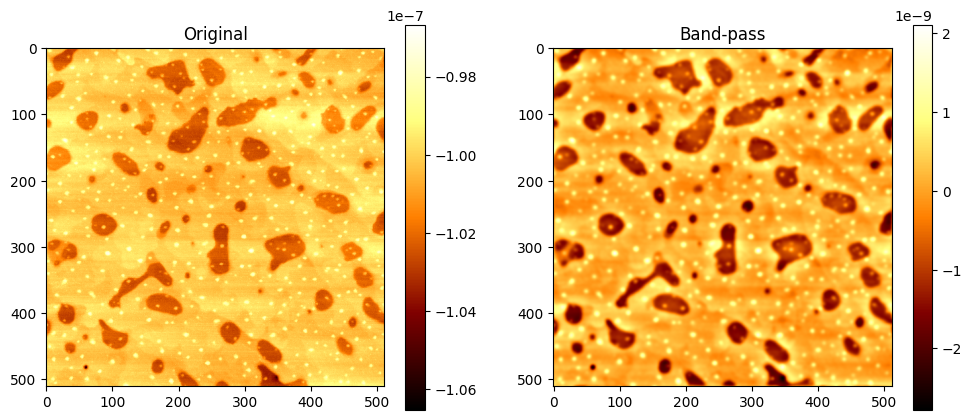

In [20]:
z_filtered = fft_bandpass(
    z,
    low_sigma=5,
    high_sigma=40
)


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(z, cmap="afmhot")
plt.title("Original")
plt.colorbar()


plt.subplot(1,2,2)
plt.imshow(z_filtered, cmap="afmhot")
plt.title("Band-pass")
plt.colorbar()


plt.show()

Quantum dots appear as halo effect on the FFT, so we can quantify them using FFT or at least try finding their characteristics

The distance from the center corresponds to the inverse of your spatial distances 1/lambda. The angle of the spots indicates the alignment direction of the dots (e.g., self-assembled linear chains along specific crystallographic step edges) 
https://www.sciencedirect.com/science/article/pii/S0169433223001940?__cf_chl_f_tk=YJBFMlXXGtf3M5XObAKVd4wQ49Iv38h0nNXggozaJw0-1783435783-1.0.1.1-FPUAAJPymiutSDDc3XulPfOcpp64fsEhst8XZy4TOx8 

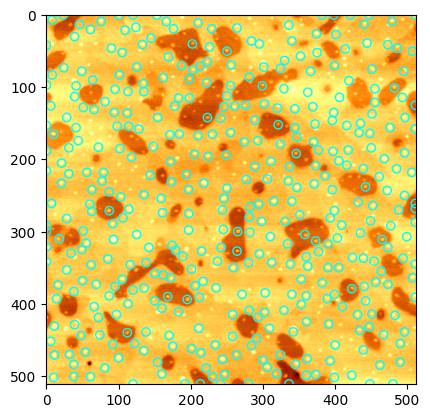

In [ ]:
from skimage.feature import blob_log


from skimage.filters import gaussian, sobel, threshold_otsu
from skimage.morphology import remove_small_objects
import matplotlib.pyplot as plt

z_norm = (
    z_filtered - np.mean(z_filtered)
) / np.std(z_filtered)

z_norm = gaussian(z_norm, sigma=1)

blobs = blob_log(
    z_norm,
    min_sigma=2, # values are in pixels, so works just like imagej
    max_sigma=8,
    num_sigma=20,
    threshold=0.5
)

plt.imshow(z, cmap="afmhot")

plt.scatter(
    blobs[:,1],
    blobs[:,0],
    facecolors="none",
    edgecolors="cyan"
)

plt.show()

In [22]:
print(len(blobs))

396


Applying an edge filter to ensure nothing is outside the edges of the QD and so that we see what python thinks is a dot


1. Sobel = default, estimates gradients with weighting the middle row/ colun more strongly so Sobel does some smoothing while finding edges. Used when you want a stable general-purpose edge map 

2. Scharr = sharper and more rotationally symmetric than Sobel but ofter better when you care about edge direction not being biased by pixel-grid orientation. Use when sobel looks slightly uneven or directional 

3. Prewitt = does less smoothing than Sobel, so can be more sensitive to noise 

4. Roberts = reacts to very local diagonal changes. Used when you want very fine local edges.

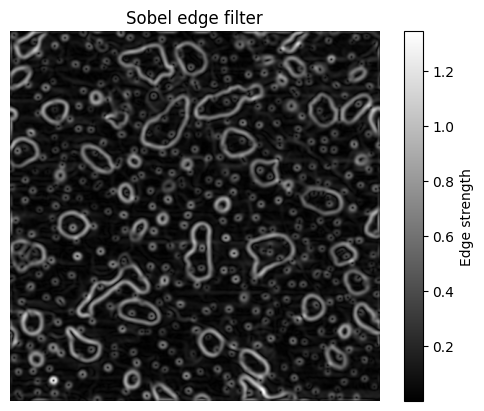

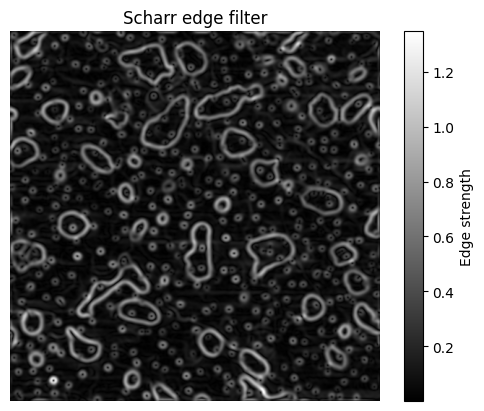

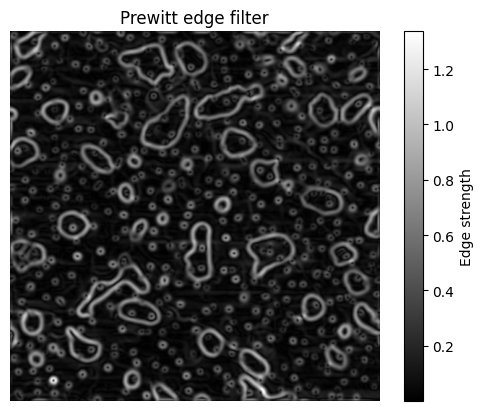

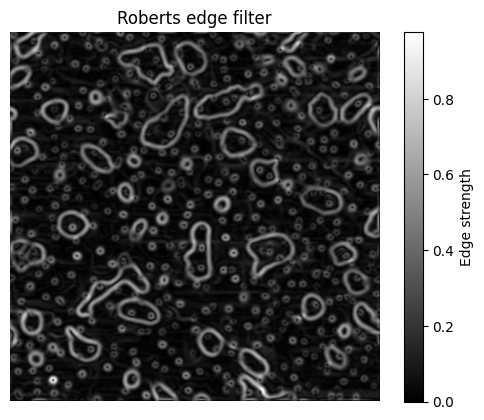

In [23]:
import matplotlib.pyplot as plt
from skimage import filters

sobel_edges = filters.sobel(z_norm)
scharr_edges = filters.scharr(z_norm)
prewitt_edges = filters.prewitt(z_norm)
roberts_edges = filters.roberts(z_norm)

plt.imshow(sobel_edges, cmap="gray")
plt.colorbar(label="Edge strength")
plt.title("Sobel edge filter")
plt.axis("off")
plt.show()

plt.imshow(scharr_edges, cmap="gray")
plt.colorbar(label="Edge strength")
plt.title("Scharr edge filter")
plt.axis("off")
plt.show()

plt.imshow(prewitt_edges, cmap="gray")
plt.colorbar(label="Edge strength")
plt.title("Prewitt edge filter")
plt.axis("off")
plt.show()

plt.imshow(roberts_edges, cmap="gray")
plt.colorbar(label="Edge strength")
plt.title("Roberts edge filter")
plt.axis("off")
plt.show()

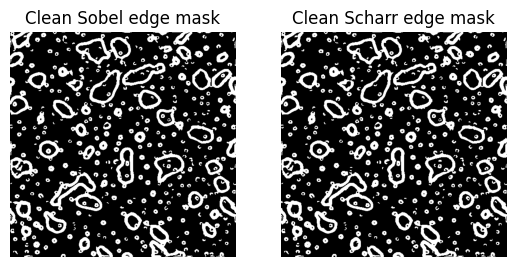

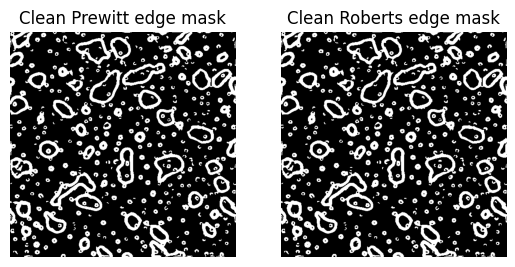

In [24]:
# 3. Threshold
threshold = threshold_otsu(sobel_edges)
edge_mask_sobel = sobel_edges > threshold

threshold = threshold_otsu(scharr_edges)
edge_mask_scharr = scharr_edges < threshold

threshold = threshold_otsu(prewitt_edges)
edge_mask_prewitt = prewitt_edges < threshold

threshold = threshold_otsu(roberts_edges)
edge_mask_roberts = roberts_edges < threshold

# 4. Clean tiny noise objects

edge_mask_clean_sobel = remove_small_objects(edge_mask_sobel, min_size=8)
edge_mask_clean_scharr = remove_small_objects(edge_mask_sobel, min_size=8)
edge_mask_clean_prewitt = remove_small_objects(edge_mask_sobel, min_size=8)
edge_mask_clean_roberts = remove_small_objects(edge_mask_sobel, min_size=8)

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(edge_mask_clean_sobel, cmap="gray")
ax1.set_title("Clean Sobel edge mask")
ax1.axis('off')

ax2.imshow(edge_mask_clean_scharr, cmap="gray")
ax2.set_title("Clean Scharr edge mask")
ax2.axis('off')

fig, (ax3, ax4) = plt.subplots(1, 2)

ax3.imshow(edge_mask_clean_prewitt, cmap="gray")
ax3.set_title("Clean Prewitt edge mask")
ax3.axis("off")

ax4.imshow(edge_mask_clean_roberts, cmap="gray")
ax4.set_title("Clean Roberts edge mask")
ax4.axis("off")


plt.show()

These all looked the same, so felt like subtracting them:

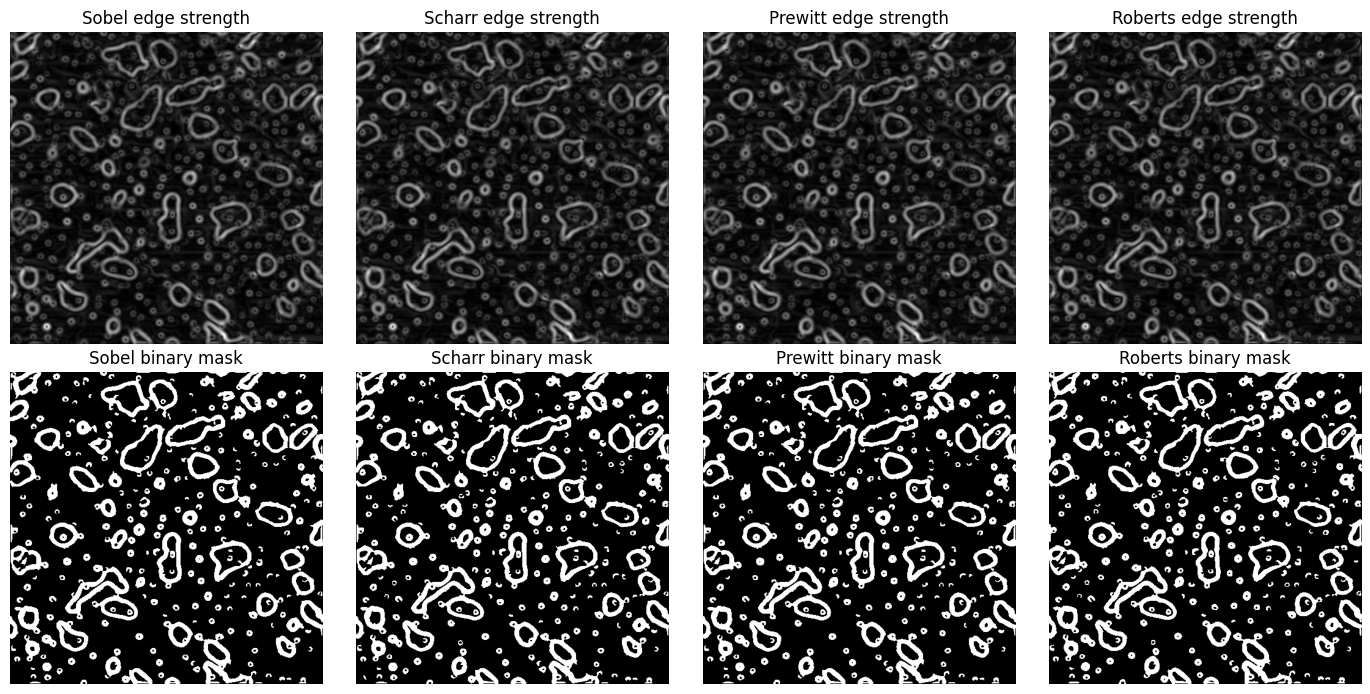

In [25]:
from skimage.filters import gaussian, sobel, scharr, prewitt, roberts
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects
import matplotlib.pyplot as plt

# topo = your AFM/topography array

topo_smooth = gaussian(z_norm, sigma=1, preserve_range=True)

edge_maps = {
    "Sobel": sobel(topo_smooth),
    "Scharr": scharr(topo_smooth),
    "Prewitt": prewitt(topo_smooth),
    "Roberts": roberts(topo_smooth),
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, (name, edges) in enumerate(edge_maps.items()):
    # continuous edge strength
    axes[0, i].imshow(edges, cmap="gray")
    axes[0, i].set_title(f"{name} edge strength")
    axes[0, i].axis("off")

    # binary mask
    threshold = threshold_otsu(edges)
    mask = edges > threshold
    mask = remove_small_objects(mask, min_size=20)

    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title(f"{name} binary mask")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

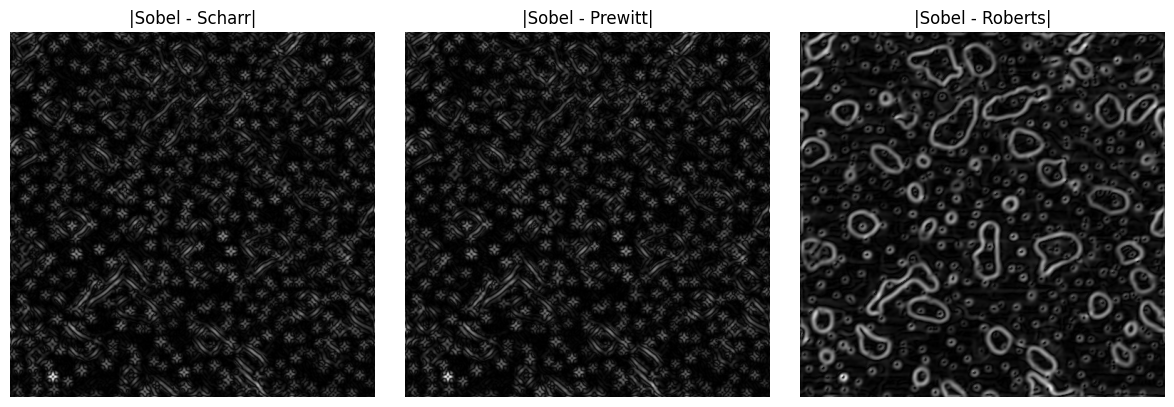

In [26]:
sobel_edges = edge_maps["Sobel"]
scharr_edges = edge_maps["Scharr"]
prewitt_edges = edge_maps["Prewitt"]
roberts_edges = edge_maps["Roberts"]

diff_sobel_scharr = abs(sobel_edges - scharr_edges)
diff_sobel_prewitt = abs(sobel_edges - prewitt_edges)
diff_sobel_roberts = abs(sobel_edges - roberts_edges)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(diff_sobel_scharr, cmap="gray")
axes[0].set_title("|Sobel - Scharr|")
axes[0].axis("off")

axes[1].imshow(diff_sobel_prewitt, cmap="gray")
axes[1].set_title("|Sobel - Prewitt|")
axes[1].axis("off")

axes[2].imshow(diff_sobel_roberts, cmap="gray")
axes[2].set_title("|Sobel - Roberts|")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [27]:
import numpy as np

for name, edges in edge_maps.items():
    diff = np.mean(np.abs(sobel_edges - edges))
    print(f"Mean absolute difference Sobel vs {name}: {diff:.6f}")

Mean absolute difference Sobel vs Sobel: 0.000000
Mean absolute difference Sobel vs Scharr: 0.000533
Mean absolute difference Sobel vs Prewitt: 0.000710
Mean absolute difference Sobel vs Roberts: 0.053573


![Top Hat filter choosing bounds](Screenshot%202026-07-08%20at%2013.06.12.png)

Using these boundaries to estimate the top hat transform boundaries. with the consideration that 1 pixel is approximately 2nm

Largest dot has diameter 25nm, so k=2*d+1=51

Image shape: (512, 512)
Image min/max: 0 255


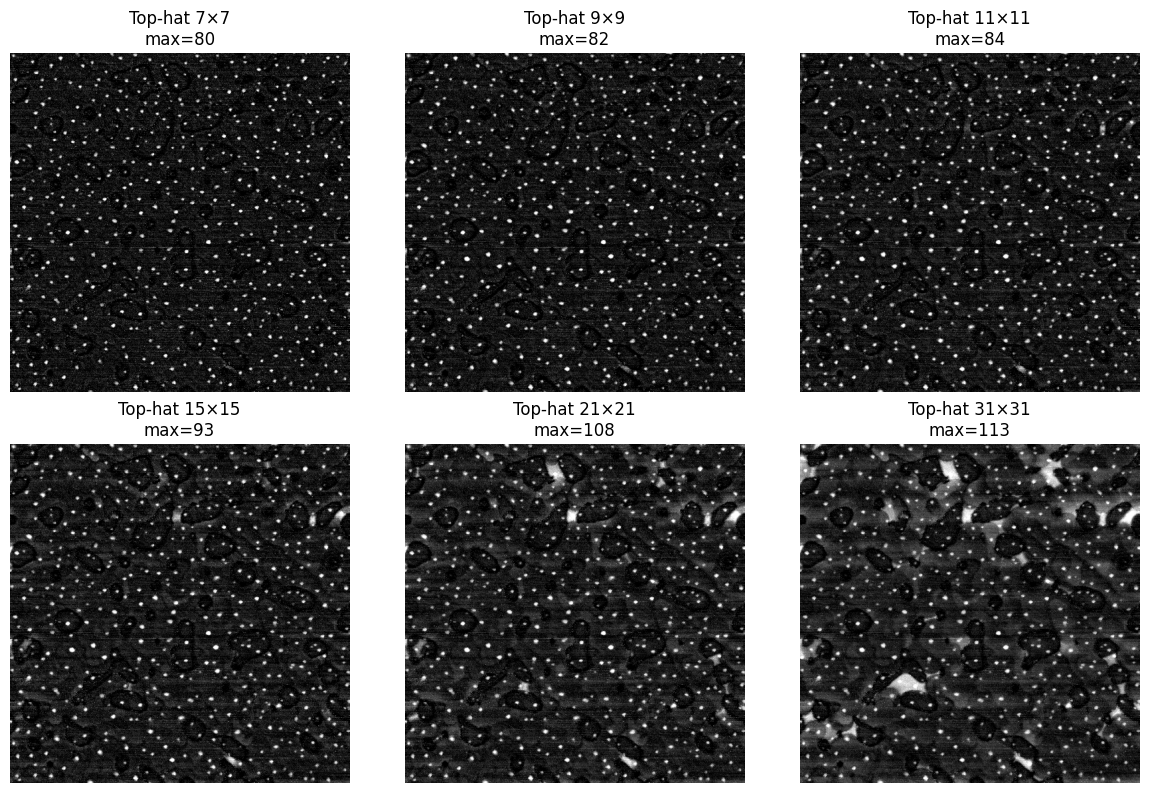

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = "2nm QD AFMs/AIX6461_along the flat edge_1um_200pN_15gain_2um zrange.0_00000_forimagej.png"

img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Could not read image: {path}")

print("Image shape:", img.shape)
print("Image min/max:", img.min(), img.max())

kernel_sizes = [7, 9, 11, 15, 21, 31, 51]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, k in zip(axes.ravel(), kernel_sizes): # the zip function pairs each plot with the kernel size. and these then get flattened so that we get one large plot with many subplots 
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)

    # contrast stretch for display
    vmin = np.percentile(tophat, 1)
    vmax = np.percentile(tophat, 99.7)

    ax.imshow(tophat, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"Top-hat {k}×{k}\nmax={tophat.max()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**For each kernel size: <br>**
<br>
    1. create a circular kernel of that size <br>
    2. use it to remove smooth/ large background <br>
    3. strertch contrast so weak details are visible <br>
    4. show the result in the next subplot

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from skimage.filters import gaussian
from skimage.feature import blob_log

kernel_sizes = [7, 9, 11, 15, 21, 31, 51]


z_float = z.astype(np.float32)

# Normalize to 0-255 because OpenCV morphology works nicely on uint8 images
z_255 = cv2.normalize(
    z_float,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


tophat_results = {}
norm_results = {}
blob_results = {}


for k in kernel_sizes:
    # Make an elliptical structuring element of size k x k
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (k, k)
    )

    # Apply white top-hat filter
    z_tophat = cv2.morphologyEx(
        z_255,
        cv2.MORPH_TOPHAT,
        kernel
    )

    # Convert to float for skimage / numerical operations
    z_filtered = z_tophat.astype(np.float32)

    # Z-score normalization
    z_norm = (
        z_filtered - np.mean(z_filtered)
    ) / (np.std(z_filtered) + 1e-8)

    # Smooth before blob detection
    z_norm_smooth = gaussian(
        z_norm,
        sigma=1,
        preserve_range=True
    )

    # Detect blobs on the filtered/smoothed image
    blobs = blob_log(
        z_norm_smooth,
        min_sigma=2,
        max_sigma=10,
        num_sigma=20,
        threshold=0.8
    )

    # Convert sigma to approximate radius
    if len(blobs) > 0:
        blobs[:, 2] = blobs[:, 2] * np.sqrt(2)

    # Store everything
    tophat_results[k] = z_tophat
    norm_results[k] = z_norm_smooth
    blob_results[k] = blobs

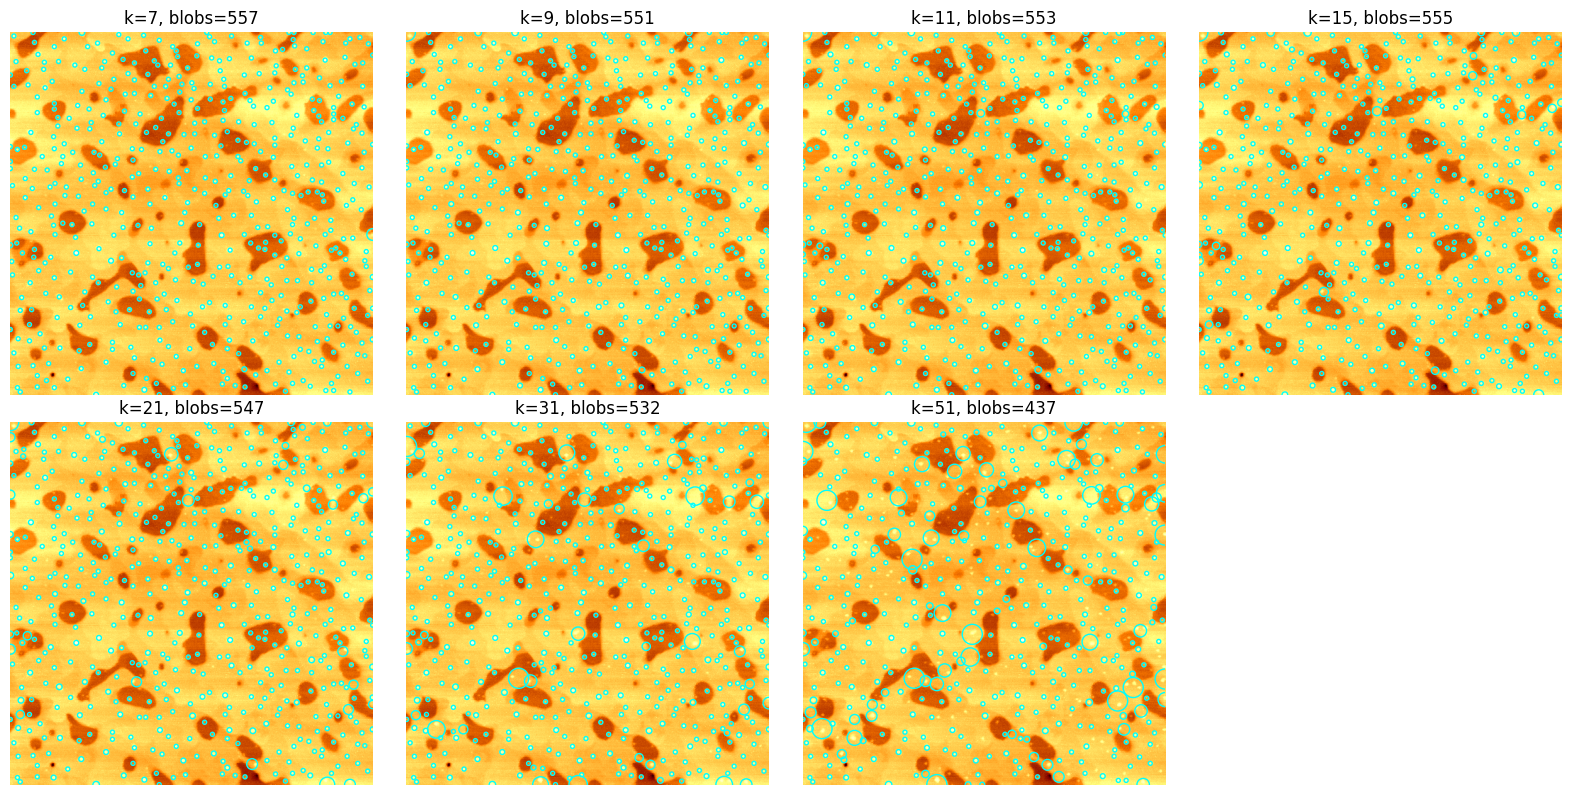

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, k in zip(axes.ravel(), kernel_sizes):
    blobs = blob_results[k]

    ax.imshow(z, cmap="afmhot")

    for y, x, r in blobs:
        circle = plt.Circle(
            (x, y),
            r,
            color="cyan",
            fill=False,
            linewidth=1
        )
        ax.add_patch(circle)

    ax.set_title(f"k={k}, blobs={len(blobs)}")
    ax.axis("off")

# Hide unused 8th subplot
for ax in axes.ravel()[len(kernel_sizes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Then, I tried to look at a different image so that we ensure that this choise isnt overfitting to this speific AFM scan.